In [38]:
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.feature_selection import mutual_info_regression

In [13]:
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [14]:
# ── feature groups ─────────────────────────────────────────────────────────────
CALO = [
    'total_adc', 'mean_adc', 'median_adc', 'max_adc', 'std_adc', 'adc_entropy',
    'bragg_peak_height', 'bragg_peak_position', 'bragg_peak_ratio', 'bragg_peak_to_median',
    'end_vs_start_ratio', 'last_quartile_mean', 'first_quartile_mean',
    'bragg_rise_slope', 'peak_integral_fraction', 'bragg_peak_width',
    'profile_cv', 'monotonic_rise_fraction', 'relative_peak_energy',
    'profile_skewness', 'profile_kurtosis',
]
TOPO = ['height', 'n_pixels', 'fill_fraction', 'solidity', 'n_local_maxima']
ALL_FEATURES = CALO + TOPO

In [3]:
with open("../../configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

name = (
    f"model_{cfg['model']['type']}"
    f"_latent{cfg['model']['latent']}"
    f"_ch{'_'.join(str(c) for c in cfg['model']['channels'])}"
    f"_beta{cfg['train']['beta']}"
    f"_lr{cfg['optimizer']['lr']}"
    f"_epoch{cfg['train']['epochs']}"
    f"_act{cfg['model']['activation']}"
    f"_kern{cfg['model']['kernel']}"
    f"_stride{cfg['model']['stride']}"
    f"_pad{cfg['model']['padding']}"
)

inference_dir = Path(cfg["output"]["inference_dir"]) / name

train = np.load(inference_dir / "train.npz")
val   = np.load(inference_dir / "val.npz")
kaon  = np.load(inference_dir / "kaon.npz")

train_latents = train["latents"]
train_recon   = train["recon"]
train_re      = train["re"]

val_latents   = val["latents"]
val_recon     = val["recon"]
val_re        = val["re"]

kaon_latents  = kaon["latents"]
kaon_recon    = kaon["recon"]
kaon_re       = kaon["re"]

In [4]:
features = pd.read_pickle('/Volumes/easystore/proton-kaon/features/features.pkl')
index = np.load('/Volumes/easystore/proton-kaon/training/split_p.npz')

train_features = features[features['particle_type'] == 'proton'].iloc[index['train_idx']]
val_features = features[features['particle_type'] == 'proton'].iloc[index['val_idx']]
kaon_features = features[features['particle_type'] == 'kaon']

In [16]:
X           = np.vstack([train_latents, val_latents, kaon_latents])
features_df = pd.concat([train_features, val_features, kaon_features], ignore_index=True)

particle_labels = np.array(
    [0] * len(train_latents) +
    [0] * len(val_latents)   +
    [1] * len(kaon_latents)
)

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── linear pipeline ──────────────────────────────
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge",  Ridge(alpha=1.0)),
])

In [26]:
latents = np.vstack([train_latents, val_latents, kaon_latents])
features_df = pd.concat([train_features, val_features, kaon_features], ignore_index=True)

particle_labels = np.array(
    [0] * len(train_latents) +
    [0] * len(val_latents)   +
    [1] * len(kaon_latents)
)

X  = latents
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge",  Ridge(alpha=1.0)),
])

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(16, 16),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        tol=1e-3,
    )),
])

In [27]:
records    = []
n_features = len(ALL_FEATURES)

print(f"R² comparison: {n_features} features ({len(CALO)} calo, {len(TOPO)} topo)")
print(f"N = {len(X)} events\n")

for i, feat in enumerate(ALL_FEATURES, 1):
    category = "calo" if feat in CALO else "topo"
    print(f"[{i:2d}/{n_features}] {feat}  ({category})")

    y    = features_df[feat].values.astype(float)
    mask = np.isfinite(y)
    Xm, ym, lm = X[mask], y[mask], particle_labels[mask]

    if mask.sum() < len(mask):
        print(f"         dropped {(~mask).sum()} non-finite values  →  N={mask.sum()}")

    splits = list(cv.split(Xm, lm))

    r2_linear = max(0.0, cross_val_score(
        linear_pipeline, Xm, ym, cv=splits, scoring="r2"
    ).mean())
    print(f"         linear R² = {r2_linear:.3f}")

    r2_mlp = max(0.0, cross_val_score(
        mlp_pipeline, Xm, ym, cv=splits, scoring="r2"
    ).mean())

    gap = round(r2_mlp - r2_linear, 3)
    print(f"         mlp R²    = {r2_mlp:.3f}  gap = {gap:+.3f}\n")

    records.append({
        "feature":   feat,
        "linear_r2": round(r2_linear, 3),
        "mlp_r2":    round(r2_mlp,    3),
        "gap":       gap,
        "category":  category,
    })

results = (
    pd.DataFrame(records)
    .sort_values("gap", ascending=False)
    .reset_index(drop=True)
)

print(results.to_string(index=False))

R² comparison: 26 features (21 calo, 5 topo)
N = 18693 events

[ 1/26] total_adc  (calo)
         linear R² = 0.221
         mlp R²    = 0.534  gap = +0.313

[ 2/26] mean_adc  (calo)
         linear R² = 0.222
         mlp R²    = 0.631  gap = +0.409

[ 3/26] median_adc  (calo)
         linear R² = 0.086
         mlp R²    = 0.193  gap = +0.107

[ 4/26] max_adc  (calo)
         linear R² = 0.025
         mlp R²    = 0.056  gap = +0.030

[ 5/26] std_adc  (calo)
         linear R² = 0.018
         mlp R²    = 0.071  gap = +0.053

[ 6/26] adc_entropy  (calo)
         linear R² = 0.094
         mlp R²    = 0.211  gap = +0.118

[ 7/26] bragg_peak_height  (calo)
         linear R² = 0.025
         mlp R²    = 0.056  gap = +0.030

[ 8/26] bragg_peak_position  (calo)
         linear R² = 0.116
         mlp R²    = 0.177  gap = +0.062

[ 9/26] bragg_peak_ratio  (calo)
         linear R² = 0.071
         mlp R²    = 0.152  gap = +0.081

[10/26] bragg_peak_to_median  (calo)
         linear R² = 0

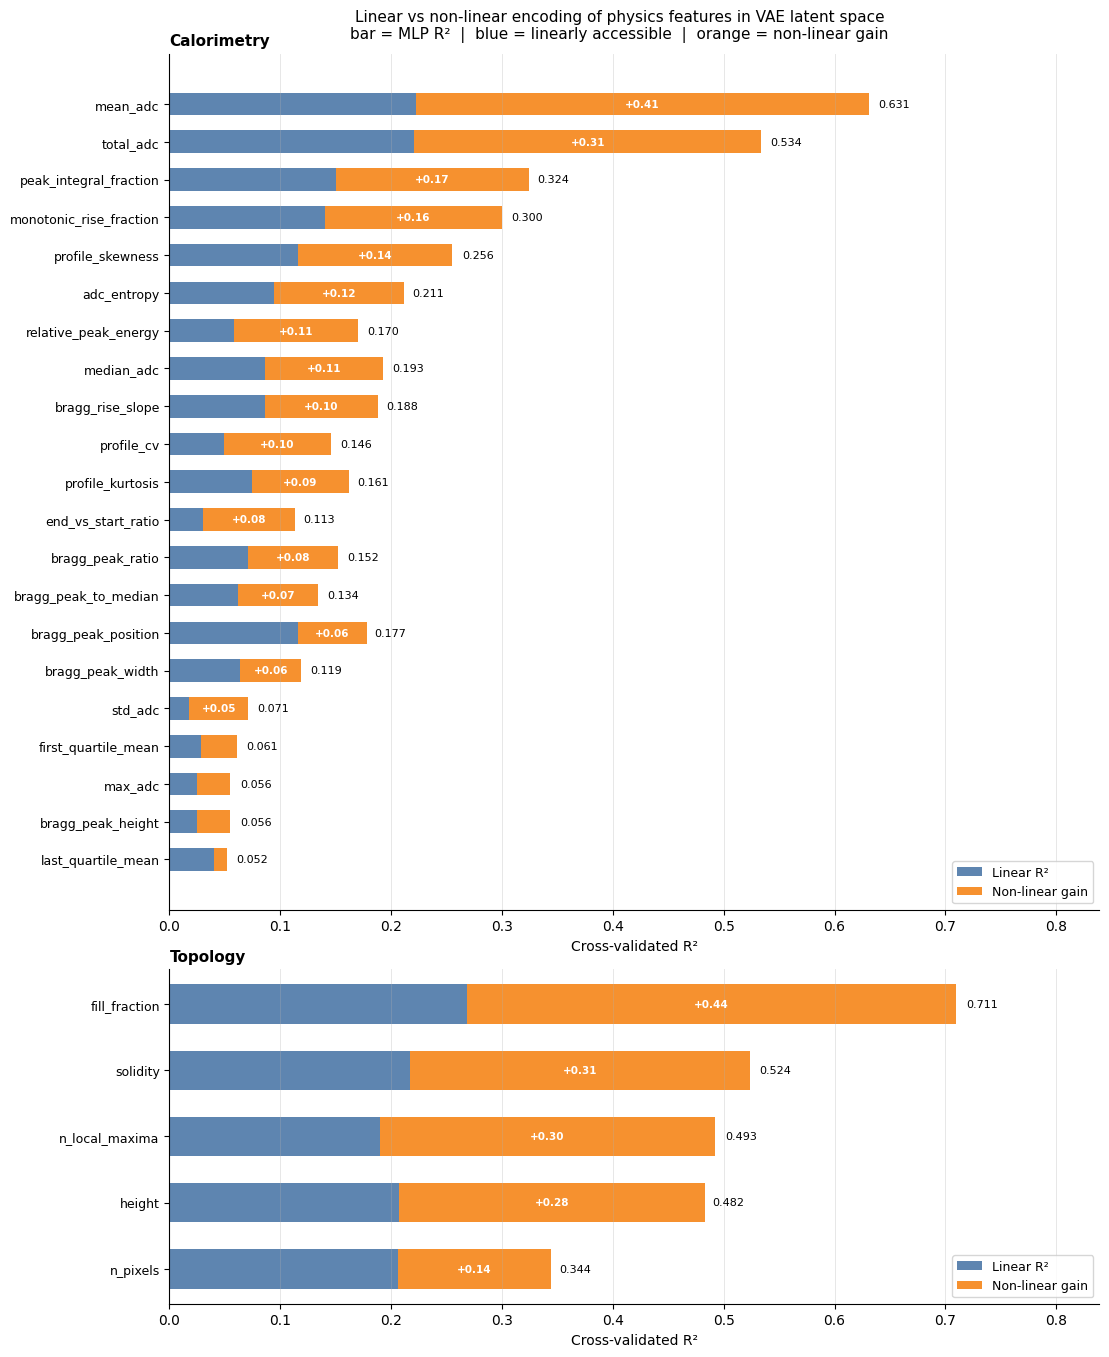

In [31]:
from matplotlib.gridspec import GridSpec

BLUE   = "#4C78A8"
ORANGE = "#F58518"

calo_df = results[results["category"] == "calo"].sort_values("gap", ascending=True)
topo_df = results[results["category"] == "topo"].sort_values("gap", ascending=True)

PX_PER_FEAT = 0.38
PAD         = 2.0
calo_h = len(calo_df) * PX_PER_FEAT + PAD
topo_h = len(topo_df) * PX_PER_FEAT + PAD

fig  = plt.figure(figsize=(12, calo_h + topo_h + 1.0))
gs = GridSpec(2, 1, figure=fig,
              height_ratios=[calo_h, topo_h],
              hspace=0.1,          # ← was 0.35
              top=0.95)
ax_c = fig.add_subplot(gs[0])
ax_t = fig.add_subplot(gs[1], sharex=ax_c)

x_max = results["mlp_r2"].max() * 1.18

for ax, df, title in zip([ax_c, ax_t], [calo_df, topo_df], ["Calorimetry", "Topology"]):
    y           = np.arange(len(df))
    h           = 0.6
    linear_vals = df["linear_r2"].values
    gap_vals    = df["gap"].clip(lower=0).values
    mlp_vals    = df["mlp_r2"].values
    feats       = df["feature"].values

    ax.barh(y, linear_vals, h, color=BLUE,   alpha=0.9, label="Linear R²")
    ax.barh(y, gap_vals,    h, color=ORANGE, alpha=0.9, left=linear_vals,
            label="Non-linear gain")

    for yi, (lin, gap, mlp) in enumerate(zip(linear_vals, gap_vals, mlp_vals)):
        ax.text(mlp + 0.008, yi, f"{mlp:.3f}",
                va="center", ha="left", fontsize=8)
        if gap > 0.04:
            ax.text(lin + gap / 2, yi, f"+{gap:.2f}",
                    va="center", ha="center", fontsize=7.5,
                    color="white", fontweight="bold")

    ax.set_yticks(y)
    ax.set_yticklabels(feats, fontsize=9)
    ax.set_xlim(0, x_max)
    ax.set_xlabel("Cross-validated R²", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="semibold", loc="left", pad=6)
    ax.grid(axis="x", alpha=0.3, linewidth=0.7)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(loc="lower right", fontsize=9, framealpha=0.8)

fig.suptitle(
    "Linear vs non-linear encoding of physics features in VAE latent space\n"
    "bar = MLP R²  |  blue = linearly accessible  |  orange = non-linear gain",
    fontsize=11, y=0.98,          # ← was 1.01
)

plt.savefig("../../figs/latents-features/nonlinear_r2.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
def permutation_importance_mlp(pipe, X, y, n_repeats=10, random_state=42):
    rng      = np.random.default_rng(random_state)
    baseline = r2_score(y, pipe.predict(X))
    n_dims   = X.shape[1]
    importances = np.zeros(n_dims)
    for i in range(n_dims):
        drops = []
        for _ in range(n_repeats):
            X_perm       = X.copy()
            X_perm[:, i] = rng.permutation(X_perm[:, i])
            drops.append(baseline - r2_score(y, pipe.predict(X_perm)))
        importances[i] = np.mean(drops)
    return importances

In [35]:
records    = []
n_features = len(ALL_FEATURES)

print(f"R² comparison: {n_features} features ({len(CALO)} calo, {len(TOPO)} topo)")
print(f"N = {len(X)} events\n")

for i, feat in enumerate(ALL_FEATURES, 1):
    category = "calorimetry" if feat in CALO else "topology"
    print(f"[{i:2d}/{n_features}] {feat}  ({category})")

    y    = features_df[feat].values.astype(float)
    mask = np.isfinite(y)
    Xm, ym, lm = X[mask], y[mask], particle_labels[mask]

    if mask.sum() < len(mask):
        print(f"         dropped {(~mask).sum()} non-finite  →  N={mask.sum()}")

    splits = list(cv.split(Xm, lm))

    # ── 1. cross-validated R² (linear + MLP) ──────────────────────────────
    r2_linear = max(0.0, cross_val_score(
        linear_pipeline, Xm, ym, cv=splits, scoring="r2"
    ).mean())
    print(f"         linear R²   = {r2_linear:.3f}")

    r2_mlp = max(0.0, cross_val_score(
        mlp_pipeline, Xm, ym, cv=splits, scoring="r2"
    ).mean())
    gap = round(r2_mlp - r2_linear, 3)
    print(f"         mlp R²      = {r2_mlp:.3f}  gap = {gap:+.3f}")

    # ── 2. fit on all data for per-particle R² + permutation importance ───
    pipe_full = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(16, 16), activation="relu",
            solver="adam", max_iter=500, random_state=42,
            early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=10, tol=1e-3,
        )),
    ])
    pipe_full.fit(Xm, ym)
    y_pred = pipe_full.predict(Xm)

    # per-particle R²
    p_mask = lm == 0
    k_mask = lm == 1
    r2_p = max(0.0, r2_score(ym[p_mask], y_pred[p_mask]))
    r2_k = max(0.0, r2_score(ym[k_mask], y_pred[k_mask]))
    print(f"         proton R²   = {r2_p:.3f}  kaon R² = {r2_k:.3f}  Δ = {r2_p - r2_k:+.3f}")

    # permutation importance
    imp = permutation_importance_mlp(pipe_full, Xm, ym)
    print(f"         perm imp    = z0:{imp[0]:.3f}  z1:{imp[1]:.3f}  z2:{imp[2]:.3f}  z3:{imp[3]:.3f}\n")

    records.append({
        "feature":   feat,
        "category":  category,
        "linear_r2": round(r2_linear, 3),
        "mlp_r2":    round(r2_mlp, 3),
        "gap":       gap,
        "r2_proton": round(r2_p, 3),
        "r2_kaon":   round(r2_k, 3),
        "gap_pk":    round(r2_p - r2_k, 3),
        "z0_imp":    round(imp[0], 4),
        "z1_imp":    round(imp[1], 4),
        "z2_imp":    round(imp[2], 4),
        "z3_imp":    round(imp[3], 4),
    })

results = (
    pd.DataFrame(records)
    .sort_values("gap", ascending=False)
    .reset_index(drop=True)
)
print(results.to_string(index=False))

R² comparison: 26 features (21 calo, 5 topo)
N = 18693 events

[ 1/26] total_adc  (calorimetry)
         linear R²   = 0.221
         mlp R²      = 0.534  gap = +0.313
         proton R²   = 0.799  kaon R² = 0.320  Δ = +0.479
         perm imp    = z0:0.508  z1:0.241  z2:0.385  z3:0.130

[ 2/26] mean_adc  (calorimetry)
         linear R²   = 0.222
         mlp R²      = 0.631  gap = +0.409
         proton R²   = 0.684  kaon R² = 0.158  Δ = +0.526
         perm imp    = z0:0.360  z1:0.227  z2:0.517  z3:0.317

[ 3/26] median_adc  (calorimetry)
         linear R²   = 0.086
         mlp R²      = 0.193  gap = +0.107
         proton R²   = 0.000  kaon R² = 0.000  Δ = +0.000
         perm imp    = z0:0.072  z1:0.144  z2:0.063  z3:0.154

[ 4/26] max_adc  (calorimetry)
         linear R²   = 0.025
         mlp R²      = 0.056  gap = +0.030
         proton R²   = 0.000  kaon R² = 0.013  Δ = -0.013
         perm imp    = z0:0.020  z1:0.054  z2:0.017  z3:0.055

[ 5/26] std_adc  (calorimetry)
    

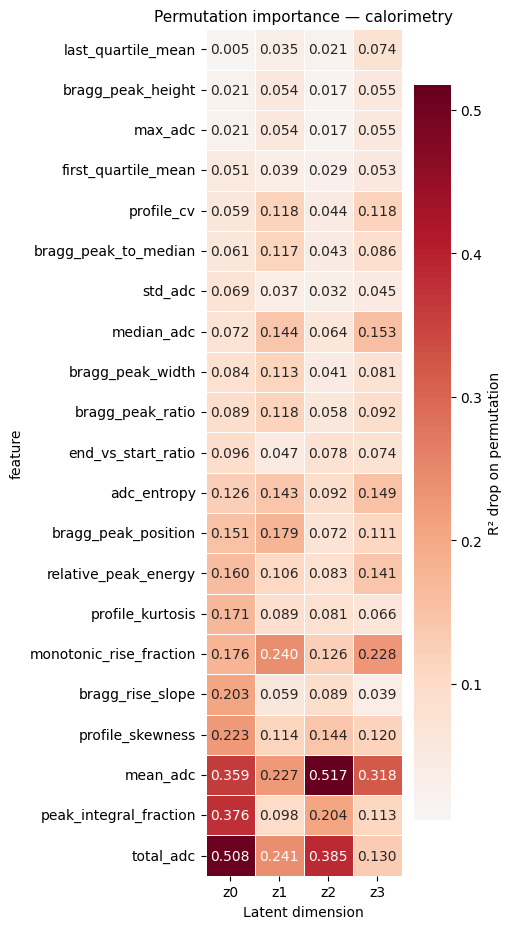

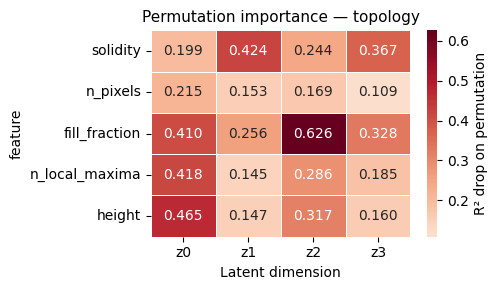

In [37]:
imp_cols = ["z0_imp", "z1_imp", "z2_imp", "z3_imp"]
rename   = {"z0_imp": "z0", "z1_imp": "z1", "z2_imp": "z2", "z3_imp": "z3"}

for category in ["calorimetry", "topology"]:
    df_cat = (
        results[results["category"] == category]
        .set_index("feature")[imp_cols]
        .rename(columns=rename)
        .sort_values("z0")          # stable row order
    )
    fig, ax = plt.subplots(figsize=(5, len(df_cat) * 0.4 + 1))
    sns.heatmap(
        df_cat, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
        linewidths=0.4, ax=ax,
        cbar_kws={"label": "R² drop on permutation"},
    )
    ax.set_title(f"Permutation importance — {category}", fontsize=11)
    ax.set_xlabel("Latent dimension")
    plt.tight_layout()
    plt.savefig(
        f"../../figs/latents-features/permutation_importance_{category}.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()

In [39]:
# ── Mutual Information analysis ──────────────────────────────────────────────

# Full latent matrix (all particles, same mask logic as before)
Z_all = X  # shape (N, 4) — already built as your feature matrix

mi_records = []

for feat in ALL_FEATURES:
    category = "calorimetry" if feat in CALO else "topology"
    y = features_df[feat].values.astype(float)
    mask = np.isfinite(y)
    Zm, ym = Z_all[mask], y[mask]

    # MI between full 4-dim latent and the feature
    mi_full = mutual_info_regression(Zm, ym, random_state=42)[0]

    # MI between each individual z_i and the feature
    mi_dims = []
    for i in range(4):
        mi_i = mutual_info_regression(Zm[:, i:i+1], ym, random_state=42)[0]
        mi_dims.append(mi_i)

    best_single = max(mi_dims)
    gap = mi_full - best_single                     # how much is lost by using best single dim
    frac_explained = best_single / mi_full if mi_full > 1e-6 else np.nan  # 1.0 = one dim sufficient

    mi_records.append({
        "feature":        feat,
        "category":       category,
        "mi_full":        round(mi_full,  4),
        "mi_z0":          round(mi_dims[0], 4),
        "mi_z1":          round(mi_dims[1], 4),
        "mi_z2":          round(mi_dims[2], 4),
        "mi_z3":          round(mi_dims[3], 4),
        "best_single":    round(best_single, 4),
        "gap":            round(gap, 4),
        "frac_explained": round(frac_explained, 3) if np.isfinite(frac_explained) else np.nan,
    })
    print(f"{feat:35s}  mi_full={mi_full:.3f}  best_z={best_single:.3f}  gap={gap:.3f}  frac={frac_explained:.2f}")

mi_df = pd.DataFrame(mi_records).set_index("feature")
print(mi_df)

total_adc                            mi_full=0.255  best_z=0.255  gap=0.000  frac=1.00
mean_adc                             mi_full=0.134  best_z=0.226  gap=-0.092  frac=1.69
median_adc                           mi_full=0.083  best_z=0.085  gap=-0.002  frac=1.03
max_adc                              mi_full=0.024  best_z=0.048  gap=-0.024  frac=2.03
std_adc                              mi_full=0.111  best_z=0.111  gap=-0.000  frac=1.00
adc_entropy                          mi_full=0.088  best_z=0.088  gap=0.000  frac=1.00
bragg_peak_height                    mi_full=0.024  best_z=0.048  gap=-0.024  frac=2.03
bragg_peak_position                  mi_full=0.243  best_z=0.243  gap=0.000  frac=1.00
bragg_peak_ratio                     mi_full=0.094  best_z=0.094  gap=0.000  frac=1.00
bragg_peak_to_median                 mi_full=0.105  best_z=0.105  gap=0.000  frac=1.00
end_vs_start_ratio                   mi_full=0.104  best_z=0.104  gap=-0.000  frac=1.00
last_quartile_mean                   

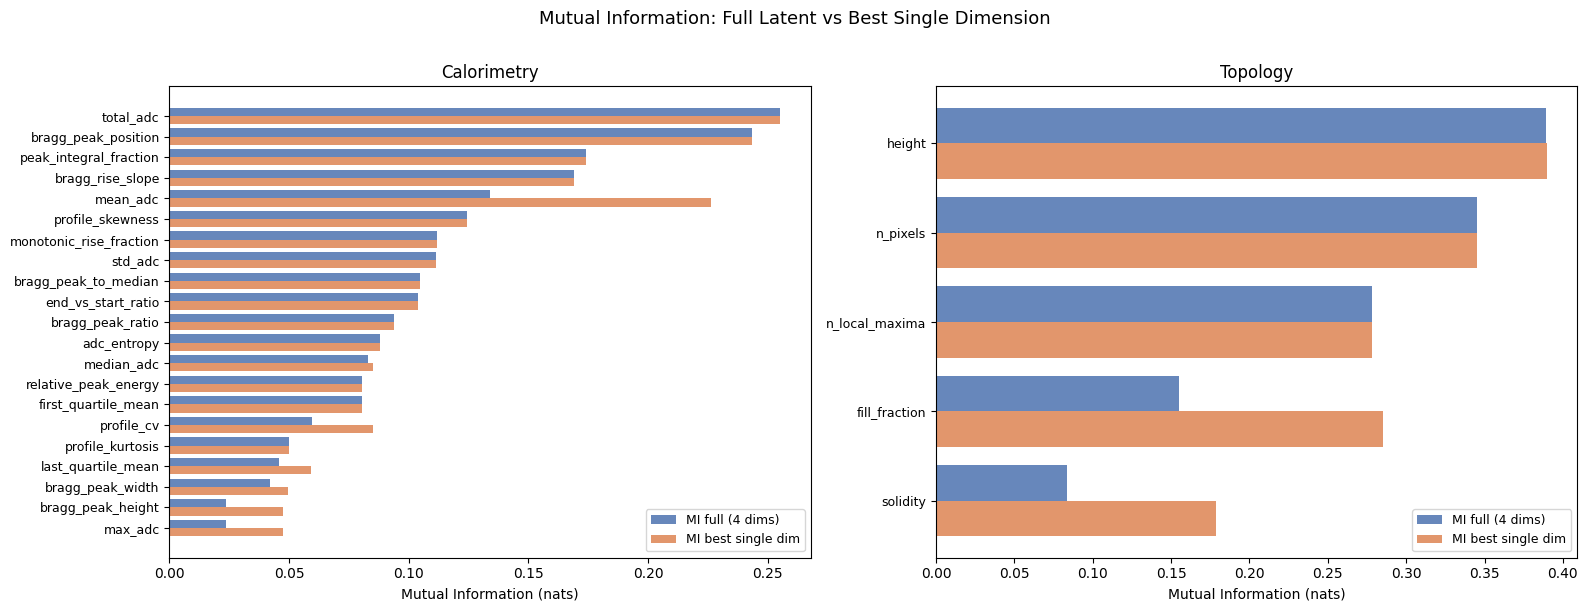

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Mutual Information: Full Latent vs Best Single Dimension", fontsize=13, y=1.01)

for ax, cat in zip(axes, ["calorimetry", "topology"]):
    sub = mi_df[mi_df["category"] == cat].copy()
    sub = sub.sort_values("mi_full", ascending=True)
    feats = sub.index.tolist()
    y_pos = np.arange(len(feats))

    ax.barh(y_pos, sub["mi_full"],      height=0.4, label="MI full (4 dims)", color="#4C72B0", alpha=0.85)
    ax.barh(y_pos - 0.4, sub["best_single"], height=0.4, label="MI best single dim", color="#DD8452", alpha=0.85)

    ax.set_yticks(y_pos - 0.2)
    ax.set_yticklabels(feats, fontsize=9)
    ax.set_xlabel("Mutual Information (nats)")
    ax.set_title(cat.capitalize())
    ax.legend(fontsize=9)
    ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig
plt.show()

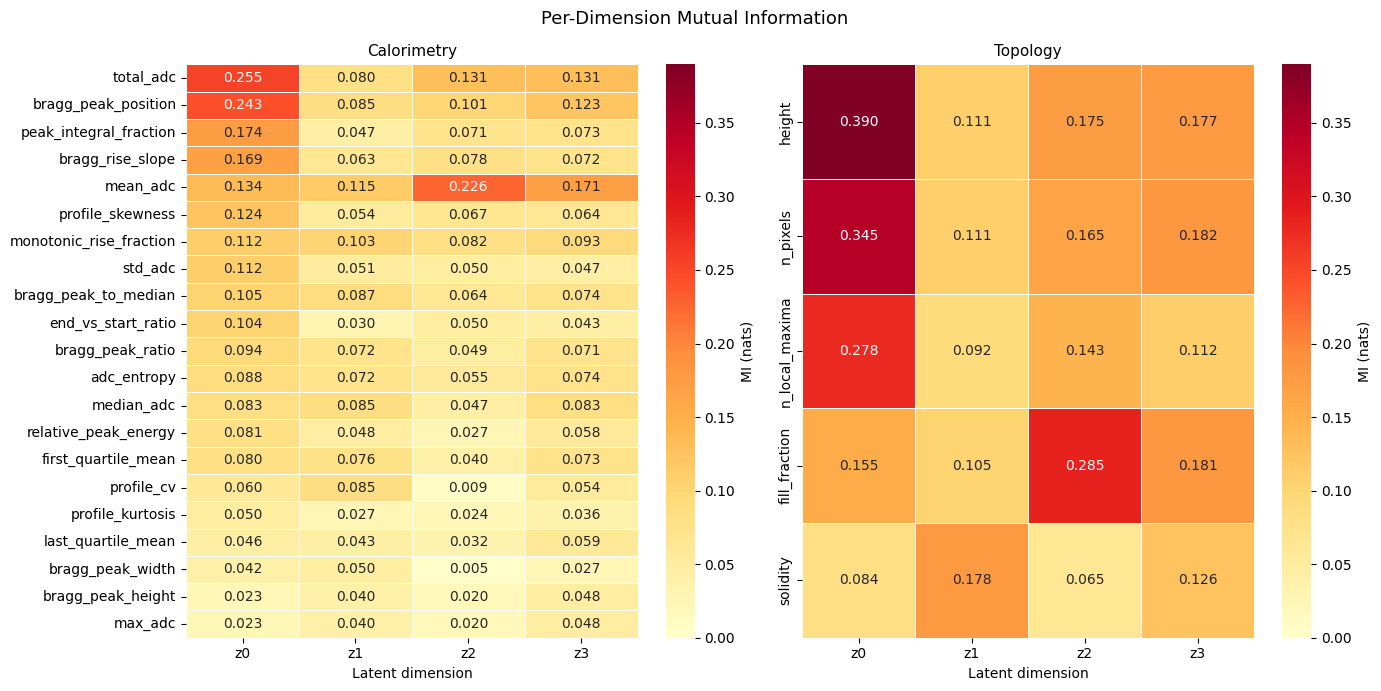

In [41]:
# Heatmap of per-dim MI (analogous to your permutation importance heatmap)
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle("Per-Dimension Mutual Information", fontsize=13, y=0.98)

for ax, cat in zip(axes, ["calorimetry", "topology"]):
    sub = mi_df[mi_df["category"] == cat][["mi_z0","mi_z1","mi_z2","mi_z3"]]
    sub.columns = ["z0", "z1", "z2", "z3"]
    sub = sub.sort_values("z0", ascending=False)

    sns.heatmap(
        sub, ax=ax, annot=True, fmt=".3f", cmap="YlOrRd",
        linewidths=0.5, cbar_kws={"label": "MI (nats)"},
        vmin=0, vmax=mi_df[["mi_z0","mi_z1","mi_z2","mi_z3"]].values.max()
    )
    ax.set_title(cat.capitalize(), fontsize=11)
    ax.set_xlabel("Latent dimension")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()